In [2]:
# | output: false
# | echo: false
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings

load_dotenv()
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [4]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [5]:
from uuid import uuid4

from langchain_core.documents import Document

document_1 = Document(
    page_content="I had chocolate chip pancakes and scrambled eggs for breakfast this morning.",
    metadata={"source": "tweet"},
)

document_2 = Document(
    page_content="The weather forecast for tomorrow is cloudy and overcast, with a high of 62 degrees.",
    metadata={"source": "news"},
)

document_3 = Document(
    page_content="Building an exciting new project with LangChain - come check it out!",
    metadata={"source": "tweet"},
)

document_4 = Document(
    page_content="Robbers broke into the city bank and stole $1 million in cash.",
    metadata={"source": "news"},
)

document_5 = Document(
    page_content="Wow! That was an amazing movie. I can't wait to see it again.",
    metadata={"source": "tweet"},
)

document_6 = Document(
    page_content="Is the new iPhone worth the price? Read this review to find out.",
    metadata={"source": "website"},
)

document_7 = Document(
    page_content="The top 10 soccer players in the world right now.",
    metadata={"source": "website"},
)

document_8 = Document(
    page_content="LangGraph is the best framework for building stateful, agentic applications!",
    metadata={"source": "tweet"},
)

document_9 = Document(
    page_content="The stock market is down 500 points today due to fears of a recession.",
    metadata={"source": "news"},
)

document_10 = Document(
    page_content="I have a bad feeling I am going to get deleted :(",
    metadata={"source": "tweet"},
)

documents = [
    document_1,
    document_2,
    document_3,
    document_4,
    document_5,
    document_6,
    document_7,
    document_8,
    document_9,
    document_10,
]
uuids = [str(uuid4()) for _ in range(len(documents))]

vector_store.add_documents(documents=documents, ids=uuids)

['4d7febe8-4955-47d2-bcd4-eddf241d01b7',
 '621ad5cb-5863-46fd-829e-9f3b1f51a84c',
 '983f67ef-11bf-469c-b979-ce8cb12bc785',
 '1051e50c-d7ac-42ee-8c10-2a31a7f3a030',
 'd1c7868b-a8fd-4293-b08d-12e9ff787a85',
 '4b308619-0346-4f20-98c7-f7e7bac70a9f',
 '1a109c29-31a0-4b27-b9d0-54eff421cfe7',
 '270f51af-7093-47cb-b844-9b7fd4519626',
 'a7c67a83-76a2-4238-9a00-5706ff3e1287',
 'ab38bf3e-5f27-4792-9471-9a227769e672']

In [6]:
results = vector_store.similarity_search(
    "LangChain provides abstractions to make working with LLMs easy",
    k=2,
    filter={"source": "tweet"},
)
for res in results:
    print(f"* {res.page_content} [{res.metadata}]")

* Building an exciting new project with LangChain - come check it out! [{'source': 'tweet'}]
* LangGraph is the best framework for building stateful, agentic applications! [{'source': 'tweet'}]


In [7]:
results = vector_store.similarity_search(
    "LangChain provides abstractions to make working with LLMs easy",
    k=2,
    filter={"source": {"$eq": "tweet"}},
)
for res in results:
    print(f"* {res.page_content} [{res.metadata}]")

* Building an exciting new project with LangChain - come check it out! [{'source': 'tweet'}]
* LangGraph is the best framework for building stateful, agentic applications! [{'source': 'tweet'}]


In [12]:

from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings()

In [11]:
faiss_db = FAISS.load_local(
    "../data/faiss_db_new",
    embedding_model,
    allow_dangerous_deserialization=True
)

In [13]:
query = "What are the myths about enterpreneurship?"

docs = faiss_db.similarity_search(query, k=3)

In [14]:
for doc in docs:
    print(doc.page_content)
    print(doc.metadata)

(Innovative Business Mindset Chapter 4: Myths Truths and Myths About Entrepreneurs)Truths and Myths About Entrepreneurs The late Jeffry Timmons, one of the early leaders in entrepreneurship education, noted that there are few truths about entrepreneurs but many myths. Among those truths, he said (LibreTexts, 2024): Entrepreneurs work hard and are driven by an intense commitment and determined perseverance; they see the cup half full, rather than half empty; they strive for integrity; they burn with the competitive desire to excel and win; they are dissatisfied with the status quo and seek opportunities to improve almost any situation they encounter; they use failure as a tool for learning and eschew perfection in favor of effectiveness; and they believe they can personally make an enormous difference in the final outcome of their ventures and their lives. The myths, however, are many. The following five entrepreneurship myths are among the most prevalent: Myth 1: Entrepreneurs are born

In [15]:
query = "What are the examples of disorders of  respiratory system?"

docs = faiss_db.similarity_search(query, k=3)

In [16]:
for doc in docs:
    print(doc.page_content)
    print(doc.metadata)

(Open RN | Medical Terminology – 2e Chapter 4 Respiratory System Terminology 4.6 Diseases and Disorders of the Respiratory System)This section provides an overview of common respiratory disorders and diseases. Allergies Allergies (ĂL-ĕr-jēz) occur when a person’s immune system reacts to a substance and makes antibodies that identify that substance as harmful. Substances identified as allergens can cause inflammation of the skin, sinuses, nasal passages, airways, or digestive system. The severity of allergies varies from person to person and can range from minor irritation to a potentially life-threatening emergency called anaphylaxis (ăn-ă-fĭ-LĂK-sĭs). While most allergies can’t be cured, allergy medications can help relieve symptoms. [1] There are many types of allergies. Allergic rhinitis, commonly referred to as “hay fever,” can cause sneezing; pruritus (PRŪ-rī-tŭs), itching of the skin, as well as itching of the nose, eyes, or roof of the mouth; rhinorrhea; and watery, red, or swol

In [1]:
from dotenv import load_dotenv
load_dotenv()


True

In [33]:
response = llm.invoke("Why did Trump attack Iran")
print("Response: ", response)

Response:  content="As of my last update in October 2023, there hasn't been any verified information or reports of former President Donald Trump ordering a military attack on Iran. However, tensions between the United States and Iran have historically been high, particularly during Trump's presidency, due to issues such as Iran's nuclear program, regional influence, and various geopolitical conflicts.\n\nIf there have been recent developments or specific events after October 2023, I would recommend checking the latest news sources for the most current and accurate information." additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 12, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_

In [13]:
import sys
sys.path.append("..")

from core.config import llm2 as llm

In [21]:
from typing import TypedDict, List

class TutorState(TypedDict):
    messages: List
    topics: List[dict]
    topic_index: int
    student_answer: str
    evaluation: str
    attempts: int

In [22]:
topics = [
    {
        "name": "Git Repository",
        "notes": "A Git repository stores project history and allows version control."
    },
    {
        "name": "Git Commit",
        "notes": "A commit records a snapshot of files in the repository."
    },
    {
        "name": "Git Branching",
        "notes": "Branches allow parallel development of features."
    }
]

In [30]:
def ask_question(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
You are a Socratic tutor.

Topic: {topic["name"]}

Notes:
{topic["notes"]}

Ask a conceptual question to test understanding.
Ask only one question.
"""
    
    response = llm.invoke(prompt)
    print("Response: ", response)
    return {
        "messages": state["messages"] + [response],
        "attempts": state["attempts"] + 1
    }

In [24]:
def evaluate_answer(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
Evaluate the student's answer.

Topic: {topic["name"]}

Reference notes:
{topic["notes"]}

Student answer:
{state["student_answer"]}

Return JSON:
{{
"understood": true/false,
"feedback": "short explanation"
}}
"""

    result = llm.invoke(prompt)

    understood = "true" in result.content.lower()

    return {
        "evaluation": result.content,
        "understood": understood,
        "messages": state["messages"] + [result]
    }

In [25]:
def give_hint(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
Student did not fully understand the concept.

Topic: {topic["name"]}

Notes:
{topic["notes"]}

Provide a hint that guides the student without revealing the full answer.
"""

    hint = llm.invoke(prompt)

    return {
        "messages": state["messages"] + [hint]
    }

In [26]:
from langgraph.graph import END

def next_topic(state):

    next_index = state["topic_index"] + 1

    if next_index >= len(state["topics"]):
        return END

    return {
        "topic_index": next_index,
        "attempts": 0
    }

In [27]:
def route_answer(state):

    if state["understood"]:
        return "next_topic"

    if state["attempts"] >= 3:
        return "next_topic"

    return "hint"

In [28]:
from langgraph.graph import StateGraph, END

builder = StateGraph(TutorState)

builder.add_node("ask", ask_question)
builder.add_node("evaluate", evaluate_answer)
builder.add_node("hint", give_hint)
builder.add_node("next_topic", next_topic)

builder.set_entry_point("ask")

builder.add_edge("ask", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    route_answer,
    {
        "hint": "hint",
        "next_topic": "next_topic"
    }
)

builder.add_edge("hint", "ask")

builder.add_edge("next_topic", "ask")

graph = builder.compile()

In [32]:
graph.get_graph().draw_mermaid()

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\task(ask)\n\tevaluate(evaluate)\n\thint(hint)\n\tnext_topic(next_topic)\n\t__end__([<p>__end__</p>]):::last\n\t__start__ --> ask;\n\task --> evaluate;\n\tevaluate -.-> hint;\n\tevaluate -.-> next_topic;\n\thint --> ask;\n\tnext_topic --> ask;\n\tevaluate -.-> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'

In [31]:
state = {
    "messages": [],
    "topics": topics,
    "topic_index": 0,
    "student_answer": "",
    "attempts": 0
}

while True:

    state = graph.invoke(state)

    tutor_message = state["messages"][-1].content
    print("\nTutor:", tutor_message)

    answer = input("You: ")

    state["student_answer"] = answer

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

In [3]:
topics = [
    {
        "name": "Git Repository",
        "notes": "A Git repository stores project files and their version history."
    },
    {
        "name": "Git Commit",
        "notes": "A commit records a snapshot of the repository at a specific point in time."
    },
    {
        "name": "Git Branch",
        "notes": "Branches allow developers to work on different features independently."
    }
]

In [4]:
from typing import TypedDict, List

class TutorState(TypedDict):
    messages: List
    topics: List
    topic_index: int
    student_answer: str
    understood: bool
    attempts: int

In [14]:
def ask_question(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
You are a Socratic tutor.

Topic: {topic['name']}

Notes:
{topic['notes']}

Ask ONE conceptual question to test understanding.
Do not reveal the answer.
"""

    response = llm.invoke(prompt)
    print("Ask question: ", response)
    return {
        "messages": state["messages"] + [response.]
    }

In [6]:
def evaluate_answer(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
Evaluate the student's answer.

Topic: {topic['name']}

Reference notes:
{topic['notes']}

Student answer:
{state['student_answer']}

Return JSON:
{{
"understood": true or false,
"feedback": "short explanation"
}}
"""

    result = llm.invoke(prompt)

    understood = "true" in result.content.lower()

    return {
        "messages": state["messages"] + [result],
        "understood": understood
    }

In [7]:
def give_hint(state):

    topic = state["topics"][state["topic_index"]]

    prompt = f"""
The student did not fully understand the concept.

Topic: {topic['name']}

Notes:
{topic['notes']}

Provide a hint that guides the student without revealing the answer.
"""

    hint = llm.invoke(prompt)

    return {
        "messages": state["messages"] + [hint],
        "attempts": state["attempts"] + 1
    }

In [8]:
def next_topic(state):

    return {
        "topic_index": state["topic_index"] + 1,
        "attempts": 0
    }

In [9]:
from langgraph.graph import END

def route_answer(state):

    if state["understood"]:
        if state["topic_index"] + 1 >= len(state["topics"]):
            return END
        return "next_topic"

    if state["attempts"] >= 2:
        return "next_topic"

    return "hint"

In [16]:
from langgraph.graph import StateGraph

builder = StateGraph(TutorState)

builder.add_node("ask", ask_question)
builder.add_node("evaluate", evaluate_answer)
builder.add_node("hint", give_hint)
builder.add_node("next_topic", next_topic)

builder.set_entry_point("ask")

builder.add_edge("ask", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    route_answer,
    {
        "hint": "hint",
        "next_topic": "next_topic",
        END: END
    }
)

builder.add_edge("hint", "ask")
builder.add_edge("next_topic", "ask")

graph = builder.compile()

In [17]:
state = {
    "messages": [],
    "topics": topics,
    "topic_index": 0,
    "student_answer": "",
    "understood": False,
    "attempts": 0
}

state = graph.invoke(state)
while True:
    tutor_message = state["messages"][-1].content
    print("\nTutor:", tutor_message)

    if state["topic_index"] >= len(topics):
        print("\nTutor: Great! You've completed all topics.")
        break

    answer = input("You: ")

    state["student_answer"] = answer
    state = graph.invoke(state)

Ask question:  content='How does a Git repository help in tracking changes made to project files over time, and why is this important for collaborative development?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 48, 'total_tokens': 73, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7c4b976237', 'id': 'chatcmpl-DJHYPSheZ28uSkRgX5xZRMNwOXrfu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019cec20-8a76-7050-a1ba-053ebc65bdb5-0' usage_metadata={'input_tokens': 48, 'output_tokens': 25, 'total_tokens': 73, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
Ask question:  content='What is th

You:  don't know


Ask question:  content='How does using branches in Git help manage the development of multiple features or bug fixes simultaneously without affecting the main codebase?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 47, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_0bb44e6ecb', 'id': 'chatcmpl-DJHeT9O47ShcyQVOfVsQM5ESkiCss', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019cec26-49be-7710-bcdb-a6c18abcac1d-0' usage_metadata={'input_tokens': 47, 'output_tokens': 24, 'total_tokens': 71, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
Ask question:  content='What i

IndexError: list index out of range

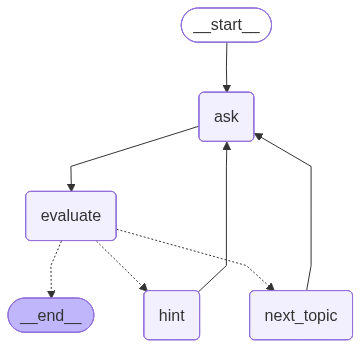

In [12]:
graph.